In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Set visual style
sns.set_theme(style="whitegrid", palette="pastel")

In [90]:
# Load Data
df_urls = pd.read_csv("Data/urls/game_highlight_urls.csv")
print("Highlights Data:")
display(df_urls.head())

df_games = pd.read_csv("Data/exposure_and_game_info/nba_games_2025-26.csv")
print("Games Data:")
display(df_games.head())

Highlights Data:


,game_id,title,url,video_id,channel,duration,view_count,like_count,comment_count
0,22500055,Oklahoma City Thunder vs Utah Jazz Full Game H...,https://www.youtube.com/watch?v=Slm2bcNEtQ4,Slm2bcNEtQ4,GAMETIME HIGHLIGHTS,567,85280,834.0,107.0
1,22500055,Oklahoma City Thunder vs Utah Jazz | Full Game...,https://www.youtube.com/watch?v=wx7dYcJpYQ8,wx7dYcJpYQ8,The CCB Network,601,4675,79.0,3.0
2,22500053,Minnesota Timberwolves vs Phoenix Suns Full Ga...,https://www.youtube.com/watch?v=xZPphKlIvhk,xZPphKlIvhk,GAMETIME HIGHLIGHTS,581,104830,1257.0,165.0
3,22500053,Minnesota Timberwolves vs Phoenix Suns | Full ...,https://www.youtube.com/watch?v=TZIB3bR3iXA,TZIB3bR3iXA,The CCB Network,623,5069,100.0,5.0
4,22500050,Toronto Raptors vs Washington Wizards Full Gam...,https://www.youtube.com/watch?v=qCZWwFr0pA0,qCZWwFr0pA0,GAMETIME HIGHLIGHTS,569,15830,189.0,3.0


Games Data:


,HOME_TEAM_ID,HOME_TEAM_ABBREVIATION,HOME_TEAM_NAME,GAME_ID,GAME_DATE,MIN,HOME_PTS,HOME_FGM,HOME_FGA,HOME_FG_PCT,HOME_FG3M,HOME_FG3A,HOME_FG3_PCT,HOME_FTM,HOME_FTA,HOME_FT_PCT,HOME_OREB,HOME_DREB,HOME_REB,HOME_AST,HOME_STL,HOME_BLK,HOME_TOV,HOME_PF,HOME_PLUS_MINUS,AWAY_TEAM_ID,AWAY_TEAM_ABBREVIATION,AWAY_TEAM_NAME,AWAY_PTS,AWAY_FGM,AWAY_FGA,AWAY_FG_PCT,AWAY_FG3M,AWAY_FG3A,AWAY_FG3_PCT,AWAY_FTM,AWAY_FTA,AWAY_FT_PCT,AWAY_OREB,AWAY_DREB,AWAY_REB,AWAY_AST,AWAY_STL,AWAY_BLK,AWAY_TOV,AWAY_PF,AWAY_PLUS_MINUS
0,1610612744,GSW,Golden State Warriors,22500056,2025-11-21,240,123,40,83,0.482,17,43,0.395,26,30,0.867,9,23,32,29,14,4,13,25,-4.0,1610612757,POR,Portland Trail Blazers,127,42,88,0.477,16,45,0.356,27,32,0.844,21,31,52,31,8,5,20,25,4.0
1,1610612761,TOR,Toronto Raptors,22500050,2025-11-21,240,140,48,83,0.578,14,28,0.500,30,39,0.769,13,35,48,36,13,4,14,20,30.0,1610612764,WAS,Washington Wizards,110,39,86,0.453,12,41,0.293,20,24,0.833,7,22,29,26,9,4,17,22,-30.0
2,1610612762,UTA,Utah Jazz,22500055,2025-11-21,240,112,38,79,0.481,16,38,0.421,20,24,0.833,12,27,39,30,10,3,27,25,-32.0,1610612760,OKC,Oklahoma City Thunder,144,51,83,0.614,23,37,0.622,19,25,0.760,3,23,26,36,15,4,13,16,32.0
3,1610612742,DAL,Dallas Mavericks,22500052,2025-11-21,239,118,40,84,0.476,16,43,0.372,22,28,0.786,11,36,47,30,9,9,20,19,3.0,1610612740,NOP,New Orleans Pelicans,115,42,91,0.462,7,27,0.259,24,31,0.774,9,33,42,25,15,4,13,20,-3.0
4,1610612739,CLE,Cleveland Cavaliers,22500048,2025-11-21,240,120,43,89,0.483,13,35,0.371,21,27,0.778,14,38,52,28,5,8,14,22,11.0,1610612754,IND,Indiana Pacers,109,37,88,0.420,11,37,0.297,24,26,0.923,10,33,43,25,10,6,12,22,-11.0


In [91]:
# How many games are covered?
print(f"Number of games: {df_urls['game_id'].nunique()}")

# How many videos in total?
print(f"Number of videos: {df_urls['video_id'].nunique()}")

# Average videos per game
avg_videos = df_urls['video_id'].nunique() / df_urls['game_id'].nunique()
print(f"Average urls per game: {avg_videos:.2f}")

Number of games: 231
Number of videos: 1320
Average urls per game: 5.71


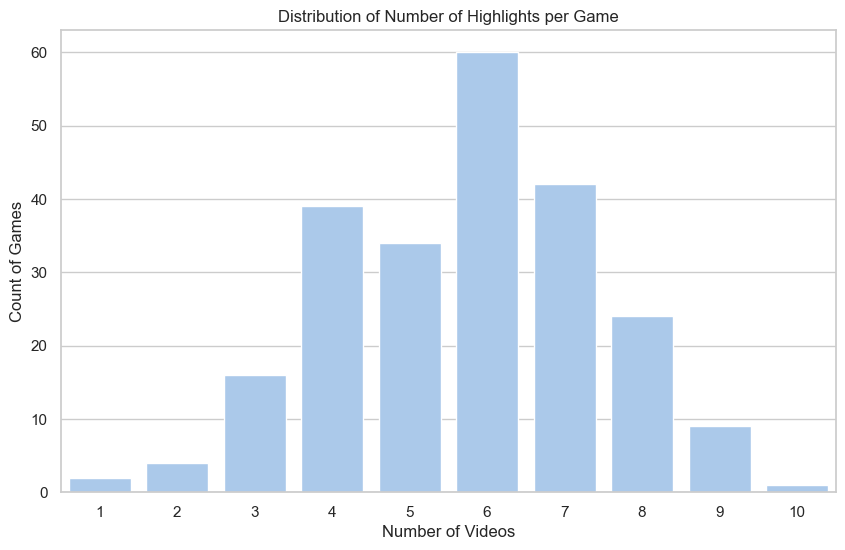

In [92]:
# Distribution of number of urls per game
nb_urls_per_game = df_urls.groupby('game_id')['video_id'].count()
df_urls['nb_urls_per_game'] = df_urls['game_id'].map(nb_urls_per_game)

plt.figure(figsize=(10, 6))
sns.countplot(x=nb_urls_per_game)
plt.title("Distribution of Number of Highlights per Game")
plt.xlabel("Number of Videos")
plt.ylabel("Count of Games")
plt.show()

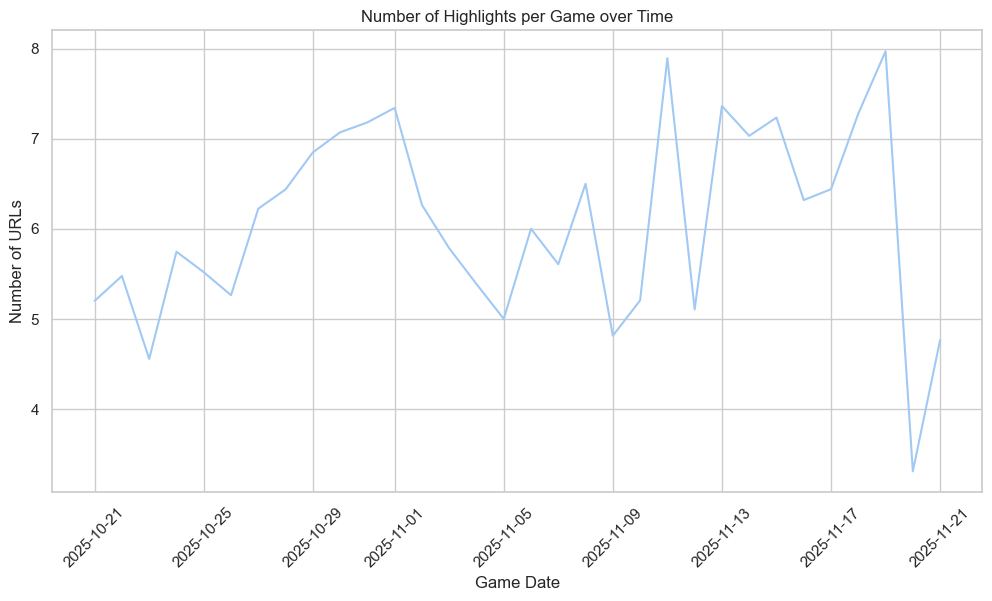

In [ ]:
# Let's check if it depends on the date of video (maybe some video get banned on yt)

# Merge with game data to get dates
df_merge = pd.merge(df_urls, df_games[['GAME_ID', 'GAME_DATE']], left_on='game_id', right_on='GAME_ID').drop(columns='GAME_ID')

# Convert to datetime for proper sorting/plotting
df_merge['GAME_DATE'] = pd.to_datetime(df_merge['GAME_DATE'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='GAME_DATE', y='nb_urls_per_game', data=df_merge, errorbar=None)
plt.title("Number of Highlights per Game over Time")
plt.xticks(rotation=45)
plt.xlabel("Game Date")
plt.ylabel("Number of URLs")
plt.show()

# Conclusion: No specific correlation found. The number of videos seems stable over time on this subsample.

--- view_count Statistics ---
count    1.321000e+03
mean     5.106892e+04
std      1.415954e+05
min      0.000000e+00
25%      1.330000e+02
50%      3.561000e+03
75%      3.478300e+04
max      2.024064e+06
Name: view_count, dtype: float64


--- like_count Statistics ---
count     1319.000000
mean       597.464746
std       1553.496762
min          0.000000
25%          2.000000
50%         88.000000
75%        386.500000
max      20057.000000
Name: like_count, dtype: float64


--- comment_count Statistics ---
count     831.000000
mean       69.371841
std       147.248589
min         1.000000
25%         4.000000
50%        12.000000
75%        61.000000
max      1400.000000
Name: comment_count, dtype: float64




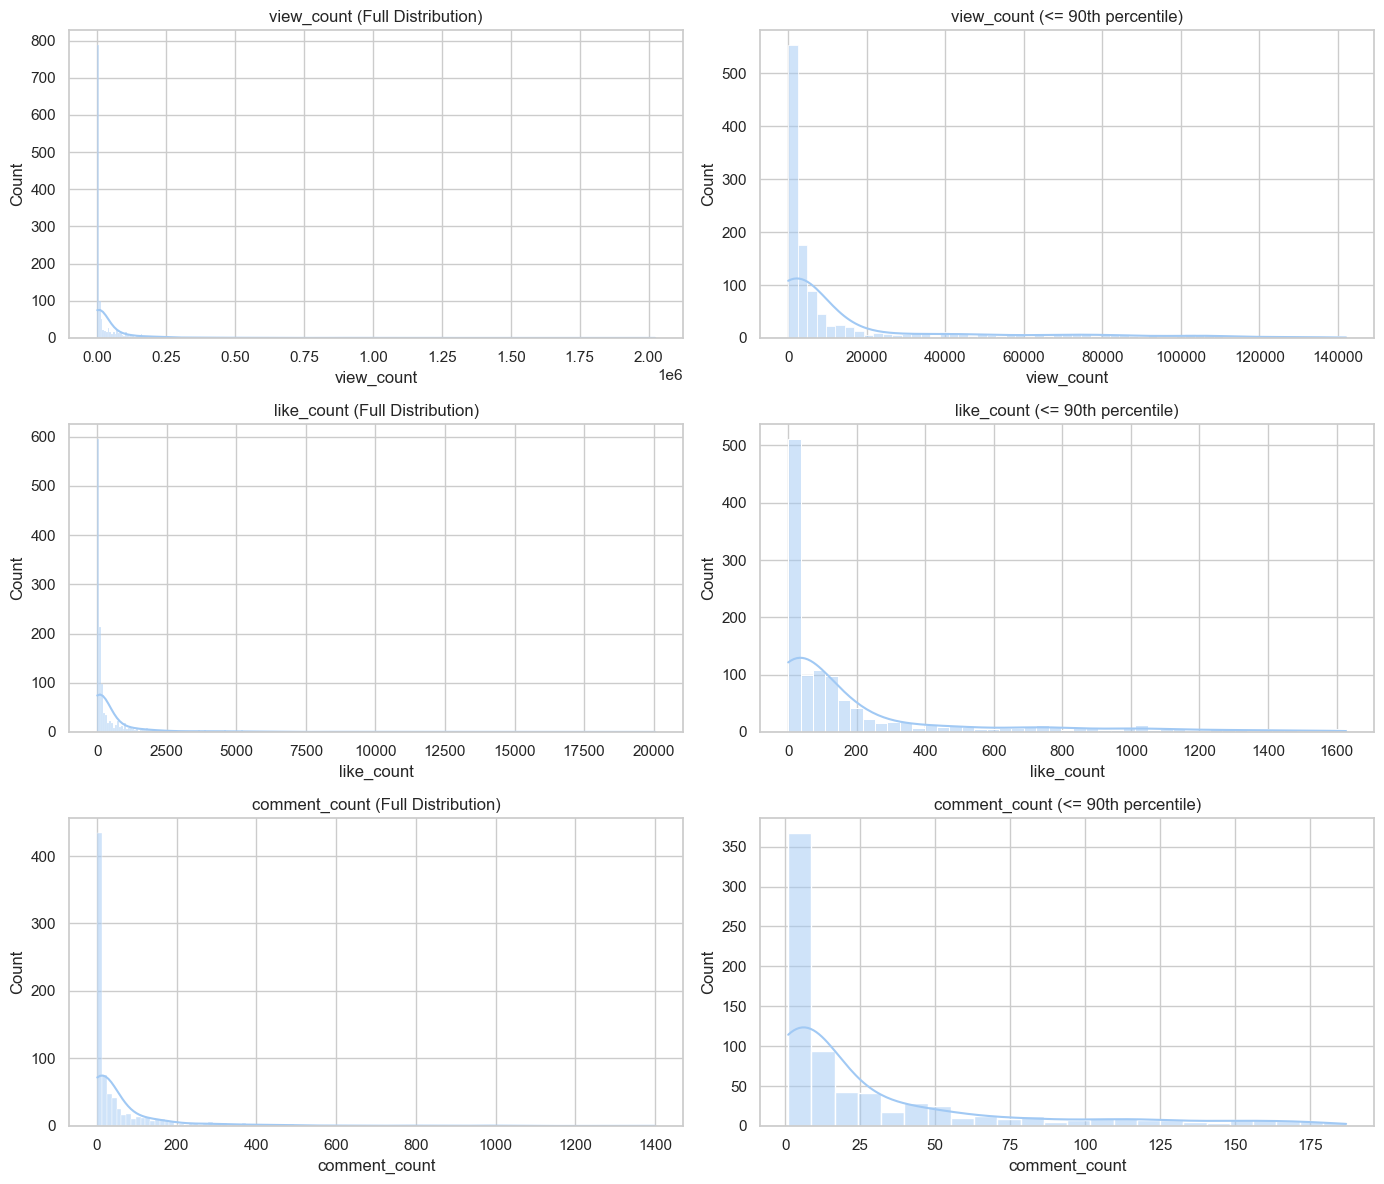

In [94]:
# Columns to analyze
cols = ['view_count', 'like_count', 'comment_count']

# Calculate 90th percentiles to zoom in on the bulk of the data
q90 = {col: df_merge[col].quantile(0.90) for col in cols}

# Create subplots: 3 rows × 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

for i, col in enumerate(cols):
    # 1. Full Histogram (Log scale might be better visually, but keeping linear as per original intent)
    sns.histplot(df_merge[col], ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"{col} (Full Distribution)")
    
    # 2. Truncated Histogram (<= 90th percentile) for better detail
    sns.histplot(df_merge[df_merge[col] <= q90[col]][col], ax=axes[i, 1], kde=True)
    axes[i, 1].set_title(f"{col} (<= 90th percentile)")

    # Print stats
    print(f"--- {col} Statistics ---")
    print(df_merge[col].describe())
    print("\n")

plt.tight_layout()
plt.show()

In [ ]:
# Some videos have 0 views, what do they look like? 

# Inspection of videos with 0 views
zero_views = df_merge[df_merge['view_count'] == 0]
print(f"Sample of videos with 0 views:\n{zero_views['url'].head(5)}")

print(f"Number of videos without views: {zero_views.shape[0]}")
print(f"Percentage of videos without views: {zero_views.shape[0] / df_merge.shape[0]:.4%}")

# After verification, these videos are valid and not anomalies; however, the view count is too low. 
# Therefore, there is no reason to keep them and run predictions on them as it is very time-consuming.

# We can therefore add a filter in the URL collection code to keep only videos above a certain view threshold.
# The threshold needs to be defined based on the relative importance of a video and the value it provides.

Sample of videos with 0 views:
59     https://www.youtube.com/watch?v=RebEKNux6Q8
117    https://www.youtube.com/watch?v=P3yziMludYA
148    https://www.youtube.com/watch?v=VkGitH9_W3g
306    https://www.youtube.com/watch?v=YKuyy7Q0H-Q
442    https://www.youtube.com/watch?v=BWxG_27SuVo
Name: url, dtype: object
Number of videos without views: 11
Percentage of videos without views: 0.8327%


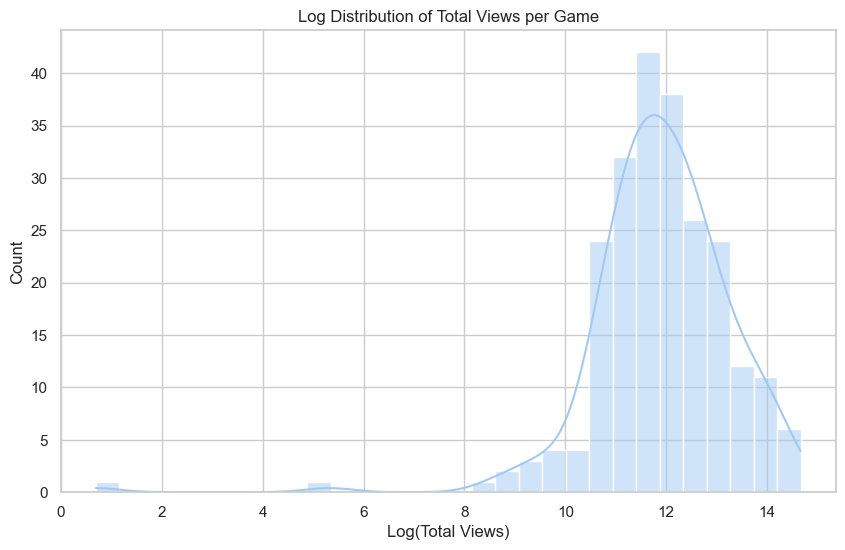

Correlation (Total Views vs Nb Videos): 0.0096
Number of videos < 1000 views: 442
Percentage of videos to be filtered out: 33.46%


In [ ]:
# Let's examine the cumulative views for each game to subsequently define a threshold

# Plotting log of total views per game
total_views_per_game = df_merge.groupby('game_id')['view_count'].sum()

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(total_views_per_game), kde=True)
plt.title("Log Distribution of Total Views per Game")
plt.xlabel("Log(Total Views)")
plt.show()

# The majority of games accumulate tens of thousands of views across an average of 5.5 videos.
# We can also verify the correlation between the number of videos available and the number of views.

# Check correlation between number of videos and total views
nb_urls_per_game = df_urls.groupby('game_id')['video_id'].count()
df_corr = pd.concat([total_views_per_game, nb_urls_per_game], axis=1)
df_corr.columns = ['total_views', 'nb_urls']

correlation = df_corr.corr().loc['total_views', 'nb_urls']
print(f"Correlation (Total Views vs Nb Videos): {correlation:.4f}")

# We can therefore state that for each game, certain videos concentrate the vast majority of views while others are ultra-minority.
# A threshold of 1000 views seems appropriate as it does not significantly impact the result, and 1/3 of the videos have fewer than 1000 views.
# This saves hours upon hours of processing time (1 video = 20 seconds) (15 * 82 regular season games * 5.5 videos per game).

low_views_count = df_merge[df_merge['view_count'] < 1000].shape[0]
print(f"Number of videos < 1000 views: {low_views_count}")
print(f"Percentage of videos to be filtered out: {low_views_count / df_merge.shape[0]:.2%}")

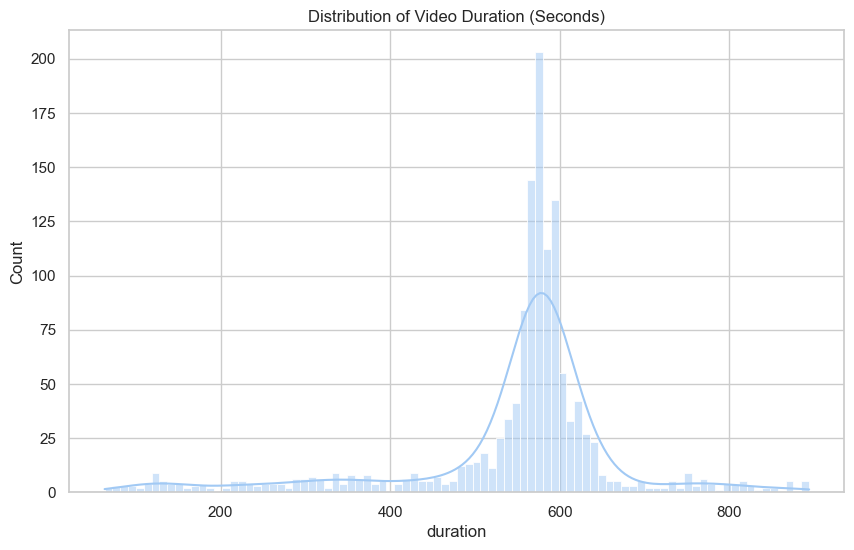

Shortest videos (Top 10):


,url,duration,view_count
498,https://www.youtube.com/watch?v=wuUKVrN0bvY,63,1
466,https://www.youtube.com/watch?v=IGwFKvH_fu8,66,3
450,https://www.youtube.com/watch?v=MaRGpcCtAPA,78,4
446,https://www.youtube.com/watch?v=kUSfZccR5R8,80,19227
1320,https://www.youtube.com/watch?v=8n-dWX8SUAI,81,904
942,https://www.youtube.com/watch?v=1fQgpfx0kFQ,84,2744
797,https://www.youtube.com/watch?v=fg_LxSqTEwc,84,14116
1148,https://www.youtube.com/watch?v=_DcsuHk2WjI,90,17508
287,https://www.youtube.com/watch?v=w0gSm0e3jGg,93,52
974,https://www.youtube.com/watch?v=x9TBpuxKS3c,96,17656


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(x='duration', data=df_merge, kde=True)
plt.title("Distribution of Video Duration (Seconds)")
plt.show()

# The majority are around 9 minutes (540s), which matches standard YouTube highlights.
# The filter fixed in the collection code prevents excessively long videos (often full gameplay or 2K simulations).

# However, very short videos deserve a look:
print("Shortest videos (Top 10):")
display(df_merge.sort_values(by='duration')[['url', 'duration', 'view_count']].head(10))

# These videos are valid, but often of poor quality (portrait mode, flickering).
# Their view counts are generally very low, so they will likely be removed by the 1000-view filter defined above.

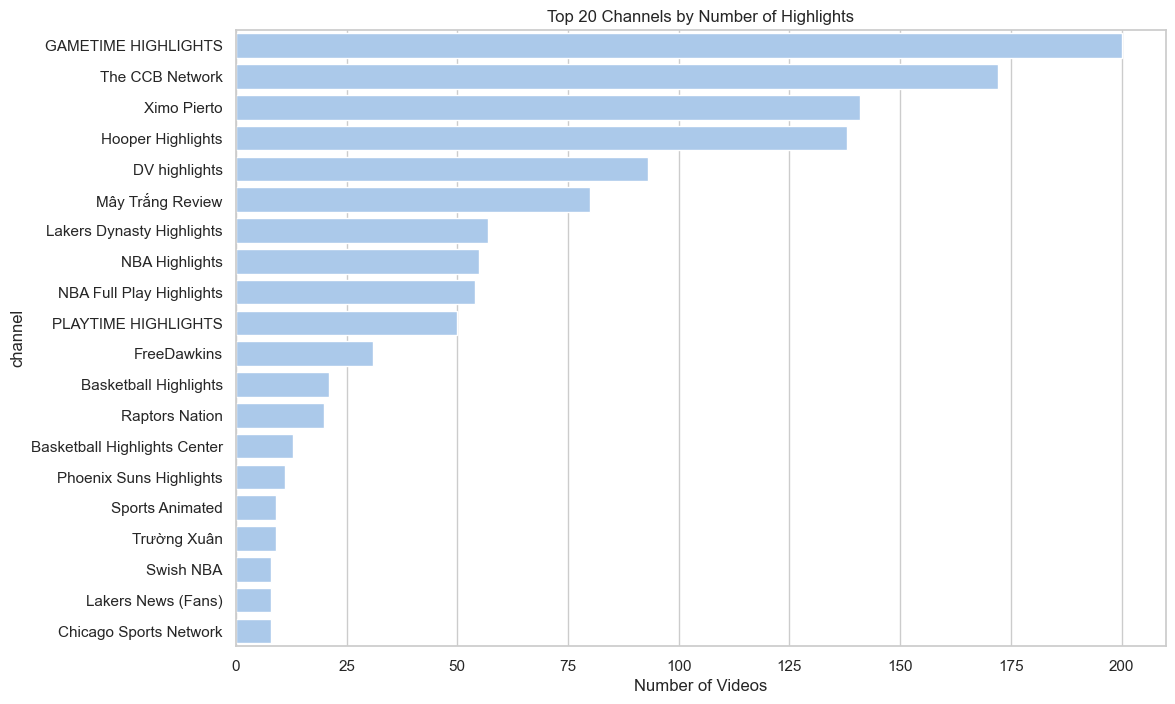

channel
GAMETIME HIGHLIGHTS          200
The CCB Network              172
Ximo Pierto                  141
Hooper Highlights            138
DV highlights                 93
Mây Trắng Review              80
Lakers Dynasty Highlights     57
NBA Highlights                55
NBA Full Play Highlights      54
PLAYTIME HIGHLIGHTS           50
Name: game_id, dtype: int64


In [ ]:
# Count videos per channel
video_per_channel = df_merge.groupby('channel')["game_id"].count().sort_values(ascending=False)

# Display Top 20 Channels
plt.figure(figsize=(12, 8))
sns.barplot(y=video_per_channel.index[:20], x=video_per_channel.values[:20])
plt.title("Top 20 Channels by Number of Highlights")
plt.xlabel("Number of Videos")
plt.show()

# Display full stats
print(video_per_channel.head(10))

# There are a few dominant channels that provide the bulk of the content.